# BGL Windowing + TF-IDF + SMOTE + XGBoost/CatBoost (Colab)

Pipeline trong notebook:
1. Sliding time window (5 phút, trượt 1 phút)
2. Vector hóa theo `EventId` với TF-IDF (kích thước = số template trong `templates.csv`)
3. Label window: có ít nhất 1 log bất thường => `Anomaly=1`, ngược lại `0`
4. Tách train/test 80/20 theo thứ tự thời gian
5. Dùng SMOTE trên tập train
6. Huấn luyện và so sánh XGBoost vs CatBoost

In [1]:
%pip install -q pandas numpy scikit-learn imbalanced-learn xgboost catboost matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [5]:
# ===== Colab file resolver =====
IN_COLAB = False
try:
    from google.colab import drive, files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')


def resolve_data_file(target_name, drive_candidates):
    candidates = [Path(p) for p in drive_candidates]
    if IN_COLAB:
        candidates += [Path('/content/drive/MyDrive') / target_name, Path('/content') / target_name]
    else:
        root = Path.cwd()
        if not (root / 'data').exists() and (root.parent / 'data').exists():
            root = root.parent
        candidates += [
            root / 'data' / 'Brain_result' / target_name,
            root / 'data' / target_name,
        ]

    for p in candidates:
        if p.exists():
            return p

    if IN_COLAB:
        print(f'Khong tim thay {target_name}. Hay upload file nay...')
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError(f'Khong co file upload cho {target_name}')
        if target_name in uploaded:
            return Path('/content') / target_name
        first_name = next(iter(uploaded.keys()))
        return Path('/content') / first_name

    raise FileNotFoundError(f'Khong tim thay {target_name}')


structured_path = resolve_data_file(
    'BGL_1500K_processed.log_structured.csv',
    [
        '/content/drive/MyDrive/AIO_Warm Up_REVIEW/AIO_The Liems/warmup03/log error classification/data/Brain_result/BGL_1500K_processed.log_structured.csv'
    ],
)

templates_path = resolve_data_file(
    'BGL_1500K_processed.log_templates.csv',
    [
        '/content/drive/MyDrive/AIO_Warm Up_REVIEW/AIO_The Liems/warmup03/log error classification/data/Brain_result/BGL_1500K_processed.log_templates.csv'
    ],
)

print('Structured:', structured_path)
print('Templates :', templates_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Structured: /content/drive/MyDrive/AIO_Warm Up_REVIEW/AIO_The Liems/warmup03/log error classification/data/Brain_result/BGL_1500K_processed.log_structured.csv
Templates : /content/drive/MyDrive/AIO_Warm Up_REVIEW/AIO_The Liems/warmup03/log error classification/data/Brain_result/BGL_1500K_processed.log_templates.csv


In [6]:
structured_cols = ['Label', 'Time', 'EventId']
df = pd.read_csv(structured_path, usecols=structured_cols)
df_templates = pd.read_csv(templates_path, usecols=['EventId'])

# giữ thứ tự EventId theo templates.csv để đảm bảo kích thước/ý nghĩa vector cố định
template_event_ids = df_templates['EventId'].astype(str).drop_duplicates().tolist()
event_to_idx = {eid: i for i, eid in enumerate(template_event_ids)}
n_templates = len(template_event_ids)

print(f'So template (so chieu vector): {n_templates}')
print(f'So dong structured: {len(df):,}')

So template (so chieu vector): 227
So dong structured: 1,500,000


In [7]:
# ===== Preprocess label/time/event =====
df['EventId'] = df['EventId'].astype(str)
df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d-%H.%M.%S.%f', errors='coerce')
df = df.dropna(subset=['Time']).copy()

label_num = pd.to_numeric(df['Label'], errors='coerce')
if label_num.notna().any():
    df['Anomaly'] = (label_num.fillna(0) > 0).astype(int)
else:
    normal_tokens = {'-', '0', 'normal', 'false', 'n'}
    df['Anomaly'] = (~df['Label'].astype(str).str.strip().str.lower().isin(normal_tokens)).astype(int)

df = df.sort_values('Time').reset_index(drop=True)
df['EventIdx'] = df['EventId'].map(event_to_idx).fillna(-1).astype(int)

print('Sau preprocess:')
print(df[['Time', 'EventId', 'Anomaly']].head())
print('\nTy le anomaly tren log-level:')
print(df['Anomaly'].value_counts(normalize=True).rename('ratio'))

Sau preprocess:
                        Time EventId  Anomaly
0 2005-06-03 15:42:50.363779      E0        0
1 2005-06-03 15:42:50.527847      E0        0
2 2005-06-03 15:42:50.675872      E0        0
3 2005-06-03 15:42:50.823719      E0        0
4 2005-06-03 15:42:50.982731      E0        0

Ty le anomaly tren log-level:
Anomaly
0    0.849537
1    0.150463
Name: ratio, dtype: float64


In [8]:
# ===== Sliding time window =====
WINDOW_MINUTES = 5
STEP_MINUTES = 1

window = pd.Timedelta(minutes=WINDOW_MINUTES)
step = pd.Timedelta(minutes=STEP_MINUTES)

time_arr = df['Time'].to_numpy(dtype='datetime64[ns]')
event_idx_arr = df['EventIdx'].to_numpy(dtype=np.int32)
anom_arr = df['Anomaly'].to_numpy(dtype=np.int8)
anom_prefix = np.concatenate(([0], np.cumsum(anom_arr)))

start_time = df['Time'].min().floor('min')
last_start = df['Time'].max() - window
if last_start < start_time:
    raise ValueError('Khoang thoi gian du lieu nho hon kich thuoc window.')

window_starts = pd.date_range(start=start_time, end=last_start, freq=step)

X_counts = []
y_windows = []
meta = []

for ws in window_starts:
    we = ws + window
    left = np.searchsorted(time_arr, np.datetime64(ws), side='left')
    right = np.searchsorted(time_arr, np.datetime64(we), side='left')

    if right <= left:
        continue  # bỏ qua window rỗng

    idx_slice = event_idx_arr[left:right]
    idx_slice = idx_slice[idx_slice >= 0]

    counts = np.bincount(idx_slice, minlength=n_templates).astype(np.float32)
    label = int((anom_prefix[right] - anom_prefix[left]) > 0)

    X_counts.append(counts)
    y_windows.append(label)
    meta.append((ws, we, right - left))

X_counts = np.vstack(X_counts)
y_windows = np.array(y_windows, dtype=np.int8)
meta_df = pd.DataFrame(meta, columns=['window_start', 'window_end', 'num_logs'])

print(f'So window (khong rong): {len(y_windows):,}')
print('Class distribution window-level:')
print(pd.Series(y_windows).value_counts(normalize=True).rename('ratio'))

So window (khong rong): 9,971
Class distribution window-level:
0    0.908635
1    0.091365
Name: ratio, dtype: float64


In [10]:
# ===== TF-IDF vectorization trên ma trận đếm EventId =====
tfidf = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True, sublinear_tf=False)
X_tfidf = tfidf.fit_transform(X_counts)

print('Shape X_tfidf:', X_tfidf.shape)
print('Kich thuoc vector co bang so template:', X_tfidf.shape[1] == n_templates)

Shape X_tfidf: (9971, 227)
Kich thuoc vector co bang so template: True


In [11]:
# ===== Temporal split 80/20 (khong shuffle) =====
split_idx = int(len(y_windows) * 0.8)

X_train = X_tfidf[:split_idx]
X_test = X_tfidf[split_idx:]
y_train = y_windows[:split_idx]
y_test = y_windows[split_idx:]
meta_train = meta_df.iloc[:split_idx].reset_index(drop=True)
meta_test = meta_df.iloc[split_idx:].reset_index(drop=True)

print(f'Train windows: {len(y_train):,} | Test windows: {len(y_test):,}')
print('Train time range:', meta_train['window_start'].min(), '->', meta_train['window_end'].max())
print('Test  time range:', meta_test['window_start'].min(), '->', meta_test['window_end'].max())

Train windows: 7,976 | Test windows: 1,995
Train time range: 2005-06-03 15:42:00 -> 2005-06-28 11:08:00
Test  time range: 2005-06-28 11:04:00 -> 2005-07-04 07:34:00


In [12]:
# ===== SMOTE tren tap train =====
X_train_dense = X_train.toarray().astype(np.float32)
X_test_dense = X_test.toarray().astype(np.float32)

minority_count = int((y_train == 1).sum())
if minority_count < 2:
    raise ValueError('So mau anomaly trong train qua it de ap dung SMOTE.')

k_neighbors = min(5, minority_count - 1)
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
X_train_smote, y_train_smote = smote.fit_resample(X_train_dense, y_train)

print('Before SMOTE:', np.bincount(y_train))
print('After  SMOTE:', np.bincount(y_train_smote))

Before SMOTE: [7211  765]
After  SMOTE: [7211 7211]


In [13]:
def evaluate_binary(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob),
    }

In [14]:
# ===== Train XGBoost =====
xgb_model = XGBClassifier(
    random_state=RANDOM_STATE,
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    tree_method='hist',
)
xgb_model.fit(X_train_smote, y_train_smote)
xgb_prob = xgb_model.predict_proba(X_test_dense)[:, 1]
xgb_metrics = evaluate_binary(y_test, xgb_prob)
xgb_metrics

{'accuracy': 0.9664160401002506,
 'precision': 1.0,
 'recall': 0.541095890410959,
 'f1': 0.7022222222222222,
 'roc_auc': np.float64(0.8959544959511622),
 'pr_auc': np.float64(0.6590620989631484)}

In [15]:
# ===== Train CatBoost =====
cat_model = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=False,
)
cat_model.fit(X_train_smote, y_train_smote)
cat_prob = cat_model.predict_proba(X_test_dense)[:, 1]
cat_metrics = evaluate_binary(y_test, cat_prob)
cat_metrics

{'accuracy': 0.9664160401002506,
 'precision': 1.0,
 'recall': 0.541095890410959,
 'f1': 0.7022222222222222,
 'roc_auc': np.float64(0.8428658215844179),
 'pr_auc': np.float64(0.5966467112987267)}

In [16]:
results_df = pd.DataFrame([
    {'model': 'XGBoost', **xgb_metrics},
    {'model': 'CatBoost', **cat_metrics},
])
results_df = results_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']]
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost,0.966416,1.0,0.541096,0.702222,0.895954,0.659062
1,CatBoost,0.966416,1.0,0.541096,0.702222,0.842866,0.596647


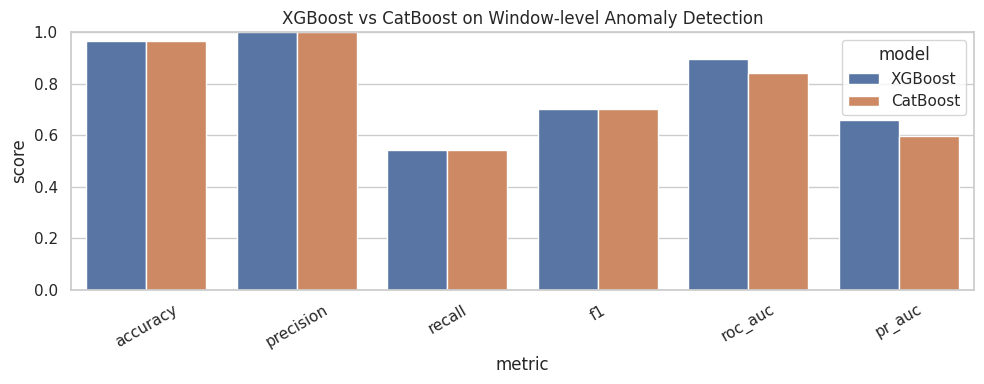

In [17]:
plot_df = results_df.melt(id_vars='model', var_name='metric', value_name='score')
plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x='metric', y='score', hue='model')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.title('XGBoost vs CatBoost on Window-level Anomaly Detection')
plt.tight_layout()
plt.show()

Sự khác biệt trung bình về xác suất: 0.001916
XGBoost - Số lượng window dự đoán là Anomaly: 79
CatBoost - Số lượng window dự đoán là Anomaly: 79
Số lượng window cả 2 mô hình dự đoán giống hệt nhau: 1995 / 1995


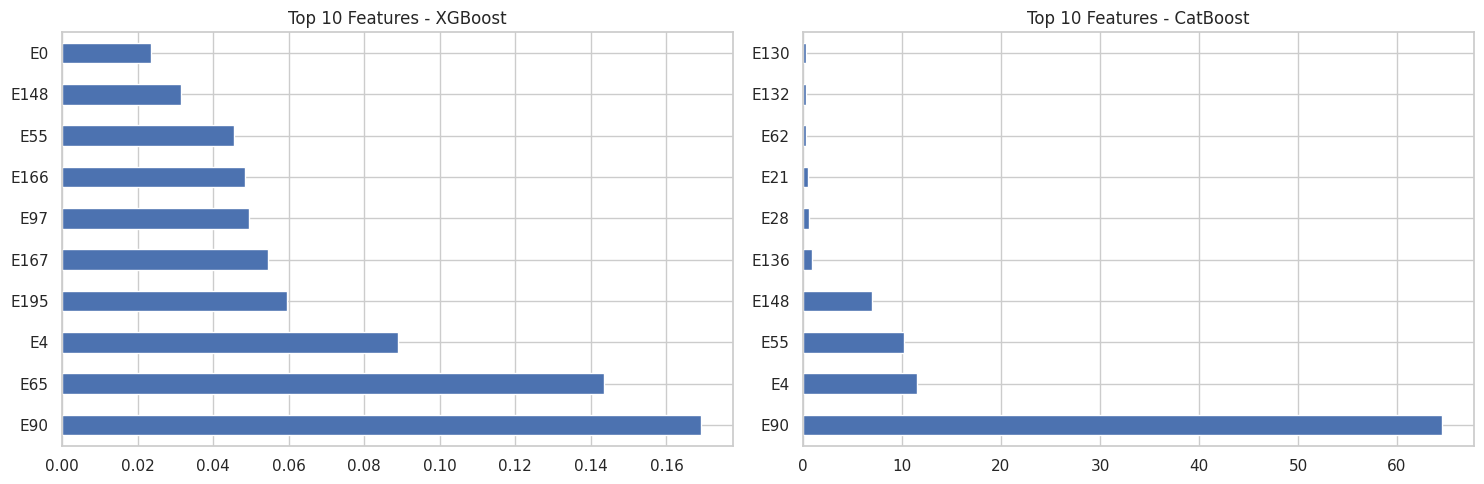

In [18]:
# 1. Kiểm tra xem mảng xác suất (probabilities) có thực sự giống hệt nhau không
diff_prob = np.abs(xgb_prob - cat_prob)
print(f"Sự khác biệt trung bình về xác suất: {diff_prob.mean():.6f}")

# 2. Kiểm tra số lượng dự đoán Positive (Anomaly=1) của mỗi mô hình
xgb_pred = (xgb_prob >= 0.5).astype(int)
cat_pred = (cat_prob >= 0.5).astype(int)

print(f"XGBoost - Số lượng window dự đoán là Anomaly: {xgb_pred.sum()}")
print(f"CatBoost - Số lượng window dự đoán là Anomaly: {cat_pred.sum()}")
print(f"Số lượng window cả 2 mô hình dự đoán giống hệt nhau: {np.sum(xgb_pred == cat_pred)} / {len(y_test)}")

# 3. Xem xét Feature Importance (Top 10 EventId quan trọng nhất)
plt.figure(figsize=(15, 5))

# XGBoost Importance
plt.subplot(1, 2, 1)
importances_xgb = pd.Series(xgb_model.feature_importances_, index=template_event_ids)
importances_xgb.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features - XGBoost')

# CatBoost Importance
plt.subplot(1, 2, 2)
importances_cat = pd.Series(cat_model.get_feature_importance(), index=template_event_ids)
importances_cat.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features - CatBoost')

plt.tight_layout()
plt.show()